# 🚲 DID 0-1 独立练习：共享单车促销活动因果评估

## 商业背景 (Business Context)

你是一家共享单车公司的 **Senior Data Analyst**。公司在 **10 个城市** 运营，为了提升日活和骑行量，运营团队在 **5 个试点城市** 推出了 "**每日首骑免费**" 促销活动。

- **处理组 (Treatment)**: 城市 5-9，从第 5 周开始 "每日首骑免费"
- **对照组 (Control)**: 城市 0-4，无任何活动
- **观测指标 (Outcome)**: 每周日均骑行订单量
- **观测周期**: 10 周（第 1-4 周为干预前，第 5-10 周为干预后）

**老板的问题**: "首骑免费到底增加了多少订单？还是只是自然增长？"

---

## 🎯 你的目标

**不看之前的 Notebook**，仅参考速查手册 `15_causal_inference.md`，独立完成 DID 全流程。

**规则**:
1. 每个 Step 先回答思考题（用 Markdown），再写代码
2. 只看速查手册，不看旧 Notebook
3. 遇到卡壳先自己想 5 分钟，实在不行再问 Agent

---

## 📚 前置：概念回顾

在写任何代码之前，先用自己的话回答以下问题：

### 🤔 思考题
1. **DID 和简单的 "前后对比" 有什么本质区别？** 为什么不能只比较促销前后的订单量变化？
2. **DID 的核心假设是什么？** 用大白话解释 "平行趋势假设"。
3. **DID 的公式是什么？** 写出 ATE 的手算公式。

👇 在下面的 Cell 中用 Markdown 回答（双击编辑）

**✏️ 你的回答**:

1. DID vs 前后对比：

2. 核心假设：

3. ATE 公式：


---

## Step 1: 数据构造 🏗️

### 🤔 思考题
**为什么 DID 需要面板数据 (Panel Data) 而不是截面数据 (Cross-sectional Data)？**

👇 先回答，再运行下面的代码

**✏️ 你的回答**:


In [1]:
# ===== Step 1: 数据构造 (已预写好，直接运行) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats

# 设置随机种子 (保证可复现)
np.random.seed(42)

# ===== 模拟参数 =====
NUM_CITIES = 10        # 总城市数
NUM_TREATED = 5        # 对照组城市数 (城市 0-4)
NUM_WEEKS = 10         # 观测周数
TREATMENT_START = 5    # 干预开始的周数
TRUE_ATE = 35          # 真实处理效应：每天增加 35 单
NOISE_STD = 10         # 噪声标准差

# 每个城市的基础日均订单量 (模拟城市间固有差异)
CITY_BASE_ORDERS = {
    0: 500, 1: 450, 2: 520, 3: 480, 4: 510,  # 对照组城市
    5: 530, 6: 470, 7: 490, 8: 540, 9: 460,  # 处理组城市
}

# 自然增长趋势 (每周自然增长 8 单)
WEEKLY_GROWTH = 8

# 构造面板数据
rows = []
for city in range(NUM_CITIES):
    is_treated = 1 if city >= NUM_TREATED else 0  # 城市 5-9 是处理组
    for week in range(1, NUM_WEEKS + 1):
        is_post = 1 if week >= TREATMENT_START else 0
        
        # 日均订单 = 城市基础值 + 自然增长 + 噪声
        orders = CITY_BASE_ORDERS[city] + WEEKLY_GROWTH * week + np.random.normal(0, NOISE_STD)
        
        # 处理组在干预后加上真实效应
        if is_treated and is_post:
            orders += TRUE_ATE
        
        rows.append({
            'city': city,
            'week': week,
            'is_treated': is_treated,
            'is_post': is_post,
            'daily_orders': round(orders, 1)
        })

df = pd.DataFrame(rows)

print(f'✅ 面板数据构造完成: {df.shape[0]} 行 × {df.shape[1]} 列')
print(f'处理组城市: {sorted(df[df["is_treated"]==1]["city"].unique())}')
print(f'对照组城市: {sorted(df[df["is_treated"]==0]["city"].unique())}')
print(f'干预前周数: Week 1-{TREATMENT_START-1}, 干预后周数: Week {TREATMENT_START}-{NUM_WEEKS}')
print(f'\n🎯 真实 ATE (你最后要估出来的): {TRUE_ATE} 单/天')
df.head(12)

✅ 面板数据构造完成: 100 行 × 5 列
处理组城市: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
对照组城市: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
干预前周数: Week 1-4, 干预后周数: Week 5-10

🎯 真实 ATE (你最后要估出来的): 35 单/天


,city,week,is_treated,is_post,daily_orders
0,0,1,0,0,513.0
1,0,2,0,0,514.6
2,0,3,0,0,530.5
3,0,4,0,0,547.2
4,0,5,0,1,537.7
5,0,6,0,1,545.7
6,0,7,0,1,571.8
7,0,8,0,1,571.7
8,0,9,0,1,567.3
9,0,10,0,1,585.4


---

## 🎯 从这里开始，全部由你自己写！

---

## Step 2: 数据探索 (EDA) 📊

### 🤔 思考题
**EDA 阶段画折线图的目的是什么？你期望看到什么样的图形？**

👇 先回答

**✏️ 你的回答**:


### 💡 提示
- 基础统计: `df.shape`, `df.describe()`, `df.head()`
- 分组折线图: `sns.lineplot(data=..., x='week', y='daily_orders', hue='is_treated')`
- 标注干预时间线: `plt.axvline(x=TREATMENT_START, color='red', linestyle='--')`
- 加标题和标签: `plt.title()`, `plt.xlabel()`, `plt.ylabel()`

In [2]:
# ✏️ 你的代码：基础统计 (shape, describe, head)
# 参考速查手册 15_causal_inference.md Step 2
display(df.head())
df.describe(include='all')

,city,week,is_treated,is_post,daily_orders
0,0,1,0,0,513.0
1,0,2,0,0,514.6
2,0,3,0,0,530.5
3,0,4,0,0,547.2
4,0,5,0,1,537.7


,city,week,is_treated,is_post,daily_orders
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,4.500000,5.500000,0.500000,0.600000,548.463000
std,2.886751,2.886751,0.502519,0.492366,46.594292
min,0.000000,1.000000,0.000000,0.000000,453.400000
25%,2.000000,3.000000,0.000000,0.000000,515.875000
50%,4.500000,5.500000,0.500000,1.000000,545.750000
75%,7.000000,8.000000,1.000000,1.000000,578.850000
max,9.000000,10.000000,1.000000,1.000000,660.100000


In [3]:
# ✏️ 你的代码：画分组折线图 + 干预时间线
# 目标：直观观察处理组 vs 对照组的趋势

WEEK_START = 5

mean_treat_group = df.groupby(['week','is_treated'])['daily_orders'].mean().reset_index()
mean_treat_group



,week,is_treated,daily_orders
0,1,0,503.30
1,1,1,506.16
2,2,0,510.36
3,2,1,518.58
4,3,0,517.66
5,3,1,519.90
6,4,0,517.66
7,4,1,530.24
8,5,0,525.70
9,5,1,569.04


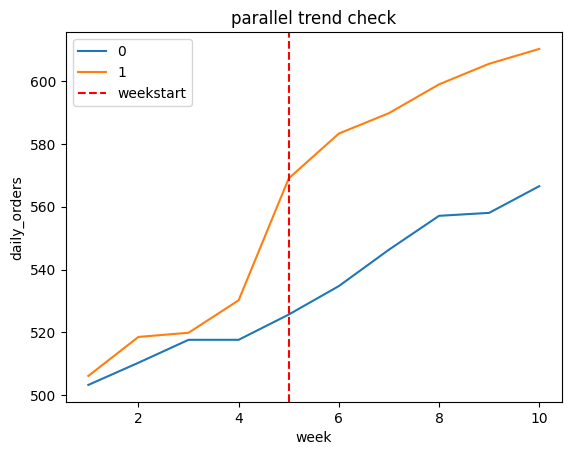

In [4]:

sns.lineplot(data=mean_treat_group,x='week',y='daily_orders',hue='is_treated',err_style='bars')
plt.axvline(x=WEEK_START,color='red',linestyle='--',label = 'weekstart')
plt.title('parallel trend check')
plt.legend()
plt.show()

---

## Step 3: 平行趋势检验 ⚠️ 核心

### 🤔 思考题
1. **什么是平行趋势假设？** 如果这个假设不成立，DID 的结论会怎样？
2. **如果平行趋势检验不通过 (P < 0.05)，你接下来应该怎么做？**

👇 先回答

**✏️ 你的回答**:

1. 平行趋势假设含义：

2. 如果不通过：


### 💡 提示 (三层递进检验)

速查手册有三层方法：
- **L1 可视化**: 看干预前两条线是否平行（已在 Step 2 画过）
- **L2 分组回归斜率对比**: 分别对处理组/对照组干预前数据跑 `smf.ols("Y ~ week")`，比较斜率
- **L3 交互项检验**: 干预前数据跑 `smf.ols("Y ~ week * is_treated")`，看交互项 P 值

关键步骤：
1. 先筛选干预前数据: `df_pre = df[df['is_post'] == 0]`
2. L2: 按 `is_treated` 分组回归，提取 `params['week']` (斜率)
3. L3: 交互项 `week:is_treated` 的 P 值 > 0.05 才算通过

In [5]:
df_pre = df[df['week']<WEEK_START]
df_pre.head()

,city,week,is_treated,is_post,daily_orders
0,0,1,0,0,513.0
1,0,2,0,0,514.6
2,0,3,0,0,530.5
3,0,4,0,0,547.2
10,1,1,0,0,453.4


In [6]:
import statsmodels.formula.api as smf 

slopes=[]
for is_treated in [0,1]:
    model_pre = smf.ols('daily_orders ~ week',data=df_pre[df_pre['is_treated'] == is_treated ]).fit()
    slopes.append({
        'is_treated':'control' if is_treated == 0 else 'treated',
        'slope': model_pre.params['week'],
        'p_value':model_pre.pvalues['week'],
        'r2':model_pre.rsquared
    })

display(pd.DataFrame(slopes))


,is_treated,slope,p_value,r2
0,control,5.038,0.415703,0.037128
1,treated,7.356,0.322605,0.054344


In [7]:
model_paralle = smf.ols('daily_orders ~ week * is_treated',data=df_pre).fit()
model_paralle_p_value = model_paralle.pvalues['week:is_treated']
print(f'p值：{model_paralle_p_value:.4f}')
# 结论：无法拒绝原假设：实验开始前斜率无显著差异





p值：0.8072


**✏️ 你的结论**: 平行趋势检验通过了吗？为什么？


---

## Step 4: DID 回归建模 📈

### 🤔 思考题
**在 `Y ~ is_treated * is_post` 这个回归公式中，交互项 `is_treated:is_post` 的系数为什么就是 ATE (Average Treatment Effect)？请用手算的逻辑解释。**

👇 先回答

**✏️ 你的回答**:


### 💡 提示
- DID 回归公式: `smf.ols("daily_orders ~ is_treated * is_post", data=df).fit()`
- 交互项 `is_treated:is_post` 的系数 = DID 估计的 ATE
- 用 `.summary()` 查看完整结果，关注：系数值、P 值、置信区间
- 与真实 ATE (35) 对比，看估计是否接近

In [8]:
# ✏️ 你的代码：DID 回归
# 1. 跑 OLS 回归
# 2. 打印 summary
# 3. 提取交互项系数，与 TRUE_ATE 对比
model_did = smf.ols('daily_orders ~ is_treated * is_post',data=df).fit()
model_did.summary()
# is_treated:is_post	38.2450	接近

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           daily_orders   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     29.41
Date:                Thu, 19 Feb 2026   Prob (F-statistic):           1.42e-13
Time:                        12:51:28   Log-Likelihood:                -492.95
No. Observations:                 100   AIC:                             993.9
Df Residuals:                      96   BIC:                             1004.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            512.2450      7.638     67.069      0.000     497.084     527.406
is_treated             6.4750     10.801      0.599      0.550     -14.965      27.915
is_post               35.8450      9.860      3.635      0.000      16.273      55.417
is_treated:is_post    38.2450     13.944      2.743      0.007      10.566      65.924
==============================================================================
Omnibus:                       10.430   Durbin-Watson:                   0.670
Prob(Omnibus):                  0.005   Jarque-Bera (JB):                3.856
Skew:                          -0.133   Prob(JB):                        0.145
Kurtosis:                       2.075   Cond. No.                         7.66
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**✏️ 你的结论**: 你估出的 ATE 是多少？和真实值 35 接近吗？P 值说明什么？


---

## Step 5: Event Study 动态效应 📉📈

### 🤔 思考题
**Event Study 能告诉你什么 DID 回归不能？为什么说它是 "可视化平行趋势 + 动态效应" 的神器？**

👇 先回答

**✏️ 你的回答**:


### 💡 提示

Event Study 的核心思想：
1. 创建相对时间变量: `df['relative_week'] = df['week'] - TREATMENT_START`
2. 为每个相对时间点生成虚拟变量（交互项）
3. 干预前的系数应该不显著 (≈0)，干预后的系数应该显著 (≈TRUE_ATE)

两种方式：
- **方式 A (手动 statsmodels)**: `smf.ols("daily_orders ~ C(relative_week):is_treated", data=df).fit()`
- **方式 B (pyfixest 自动)**: `import pyfixest as pf; est = pf.feols("daily_orders ~ i(relative_week, is_treated, ref=-1)", data=df); est.iplot()`

> 建议先试方式 B (pyfixest)，代码更简洁。如果未安装: `!pip install pyfixest`

In [9]:
# ✏️ 你的代码：创建 relative_week 变量
df['relative_week'] =df['week'] - WEEK_START


In [ ]:
# ✏️ 你的代码：Event Study 回归 + 画动态效应图
# 期望结果：干预前系数 ≈ 0，干预后系数 ≈ 35
import pyfixest as pf

fit = pf.feols('daily_orders ~ i(relative_week,is_treated,ref=-1)|city',data=df,vcov = {'CRV1':'city'})

pf.iplot(fit,figsize=(10,5),title = 'event study(pyfixest)')

# import pyfixest as pf

# fit = pf.feols("daily_orders ~ i(relative_week, is_treated, ref=-1) | city",
#                data=df, vcov={'CRV1': 'city'})

# # 1. 类似 statsmodels 的 summary 表
# fit.summary()           # 打印回归摘要（系数、标准误、t值、P值、CI）

# # 2. 提取系数（Series）
# fit.coef()              # 返回所有系数

# # 3. 提取 P 值
# fit.pvalue()            # 返回所有 P 值

# # 4. 提取标准误
# fit.se()                # 返回标准误

# # 5. 提取置信区间
# fit.confint()           # 返回 95% 置信区间 DataFrame

# # 6. 提取 t 统计量
# fit.tstat()             # 返回 t 值

# # 7. 可视化（你已经知道的）
# pf.iplot(fit)           # Event Study 系数图

# 8. 多模型对比表（面试加分！）
fit2 = pf.feols("daily_orders ~ is_treated * is_post", data=df)
pf.etable([fit, fit2])  # 像 R 的 stargazer 一样并排对比




GT(_tbl_data=   level_0                                            level_1  \
0     coef  C(relative_week, contr.treatment(base=-1))[-4]...   
1     coef  C(relative_week, contr.treatment(base=-1))[-3]...   
2     coef  C(relative_week, contr.treatment(base=-1))[-2]...   
3     coef  C(relative_week, contr.treatment(base=-1))[0]:...   
4     coef  C(relative_week, contr.treatment(base=-1))[1]:...   
5     coef  C(relative_week, contr.treatment(base=-1))[2]:...   
6     coef  C(relative_week, contr.treatment(base=-1))[3]:...   
7     coef  C(relative_week, contr.treatment(base=-1))[4]:...   
8     coef  C(relative_week, contr.treatment(base=-1))[5]:...   
9     coef                                         is_treated   
10    coef                                            is_post   
11    coef                                 is_treated:is_post   
12    coef                                          Intercept   
13      fe                                               city   
14   stats                                       Observations   
15   stats                                          S.E. type   
16   stats                                      R<sup>2</sup>   
17   stats                               R<sup>2</sup> Within   

                          0                        1  
0   -24.080*** <br> (3.366)                           
1     -11.660* <br> (4.162)                           
2      -10.340 <br> (6.291)                           
3    38.800** <br> (10.107)                           
4    53.060*** <br> (6.358)                           
5    59.560*** <br> (6.252)                           
6    68.720*** <br> (7.016)                           
7    75.280*** <br> (4.837)                           
8    80.000*** <br> (8.173)                           
9                                6.475 <br> (10.801)  
10                            35.845*** <br> (9.860)  
11                            38.245** <br> (13.944)  
12                           512.245*** <br> (7.638)  
13                        x                        -  
14                      100                      100  
15                 by: city                      iid  
16                    0.868                    0.479  
17                    0.721                        -  , _body=<great_tables._gt_data.Body object at 0x11b860290>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x11bc36b70>, _spanners=Spanners([SpannerInfo(spanner_id='daily_orders', spanner_level=1, spanner_label='daily_orders', spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x11bd692b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x11bd68560>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x11bd687a0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'

**✏️ 你的解读**: 图上干预前的系数是否接近 0？干预后呢？这说明什么？


---

## Step 6: Placebo Test (安慰剂检验) 🧪

### 🤔 思考题
**为什么说 Placebo Test 是 DID 的 "生命线"？如果 Placebo Test 发现了显著效应，意味着什么？**

👇 先回答

**✏️ 你的回答**:


### 💡 提示

两种安慰剂检验：

**6A. 时间安慰剂 (Fake Time)**:
- 只用干预前数据 (`df[df['is_post'] == 0]`)
- 假装干预在第 3 周发生: `fake_post = (week >= 3)`
- 跑 DID 回归，交互项系数应该 **不显著** (P > 0.05)

**6B. 个体安慰剂 (Fake Treatment)**:
- 只用对照组数据 (`df[df['is_treated'] == 0]`)
- 随机把一半对照城市标为 "假处理组": `fake_treated = (city >= 2)`
- 跑 DID 回归，交互项系数应该 **不显著** (P > 0.05)

In [11]:
# ✏️ 你的代码：6A 时间安慰剂 (Fake Time)
# 1. 筛选干预前数据
# 2. 创建 fake_post 变量
# 3. 跑 DID 回归
# 4. 检查交互项 P 值


In [12]:
# ✏️ 你的代码：6B 个体安慰剂 (Fake Treatment)
# 1. 筛选对照组数据
# 2. 创建 fake_treated 变量
# 3. 跑 DID 回归
# 4. 检查交互项 P 值


In [13]:
import statsmodels.formula.api as smf

# 假设真实干预从 Week 5 开始
REAL_INTERVENTION_WEEK = 5

# ===== Placebo Time: 把干预时间提前到 Week 3 =====
FAKE_INTERVENTION_WEEK = 3

# 只用干预前数据 (Week 1~4)
df_pre = df[df['week'] < REAL_INTERVENTION_WEEK].copy()

# 构造假的 is_post 变量
df_pre['is_post_fake'] = (df_pre['week'] >= FAKE_INTERVENTION_WEEK).astype(int)

# 用同样的 DID 回归公式
model_placebo = smf.ols(
    'daily_orders ~ is_treated * is_post_fake',
    data=df_pre
).fit()

print(model_placebo.summary())

# 核心判断: is_treated:is_post_fake 的系数
placebo_coef = model_placebo.params['is_treated:is_post_fake']
placebo_p = model_placebo.pvalues['is_treated:is_post_fake']
print(f'\n安慰剂效应 = {placebo_coef:.2f}, P = {placebo_p:.4f}')
print(f'结论: {"✅ 通过 (P > 0.05, 无虚假效应)" if placebo_p > 0.05 else "❌ 失败 (模型可能不可靠)"}')

                            OLS Regression Results                            
Dep. Variable:           daily_orders   R-squared:                       0.043
Model:                            OLS   Adj. R-squared:                 -0.037
Method:                 Least Squares   F-statistic:                    0.5357
Date:                Thu, 19 Feb 2026   Prob (F-statistic):              0.661
Time:                        12:51:34   Log-Likelihood:                -195.21
No. Observations:                  40   AIC:                             398.4
Df Residuals:                      36   BIC:                             405.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [14]:
import numpy as np

# 只取对照组数据
df_control = df[df['is_treated'] == 0].copy()

# 随机拆分: 把一半对照组城市标为"假处理组"
np.random.seed(42)
control_cities = df_control['city'].unique()
n_fake_treat = len(control_cities) // 2
fake_treat_cities = np.random.choice(control_cities, n_fake_treat, replace=False)
df_control['is_treated_fake'] = df_control['city'].isin(fake_treat_cities).astype(int)

# DID 回归
model_placebo2 = smf.ols(
    'daily_orders ~ is_treated_fake * is_post',
    data=df_control
).fit()

placebo_coef2 = model_placebo2.params['is_treated_fake:is_post']
placebo_p2 = model_placebo2.pvalues['is_treated_fake:is_post']
print(f'安慰剂效应 = {placebo_coef2:.2f}, P = {placebo_p2:.4f}')
print(f'结论: {"✅ 通过" if placebo_p2 > 0.05 else "❌ 失败"}')

安慰剂效应 = -0.23, P = 0.9892
结论: ✅ 通过


**✏️ 你的结论**: 两个 Placebo Test 都通过了吗？这对你的 DID 分析意味着什么？


---

## Step 7: 业务汇报 📝 (面试核心)

### 🤔 思考题
**如果老板问："为什么不直接做 A/B Test？为什么要用 DID？"，你怎么回答？**

👇 先回答

**✏️ 你的回答**:


### 💡 任务

写一份 **Executive Summary**，假设你要在周会上用 3 分钟讲清楚这个分析。

**格式要求 (面试必备结构)**:

```
## Executive Summary: 共享单车 "首骑免费" 促销效果评估

### 背景
[1-2 句话描述业务问题]

### 方法
[为什么用 DID？用了什么检验保证结论可靠？]

### 关键发现
- ATE = ？？（置信区间）
- 统计显著性：P = ？？
- 稳健性：Placebo Test 结果

### 商业建议
[基于数据给出 1-2 条可执行的建议]

### 局限性与下一步
[诚实地说出分析的不足]
```

👇 在下面写你的 Executive Summary

In [15]:
# 模板代码: 一键输出 Executive Summary
def did_executive_summary(model_did, model_event_study, model_placebo, 
                          true_ate=None, treatment_desc="促销活动"):
    """生成 DID 分析的 Executive Summary"""
    # 提取核心结果
    did_coef = model_did.params['is_treated:is_post']
    did_p = model_did.pvalues['is_treated:is_post']
    did_ci = model_did.conf_int().loc['is_treated:is_post']

    placebo_p = model_placebo.pvalues.get(
        'is_treated:is_post_fake',
        model_placebo.pvalues.get('is_treated_fake:is_post', None)
    )

    print("=" * 60)
    print(f"📊 DID 分析 Executive Summary: {treatment_desc}")
    print("=" * 60)
    print(f"\n🎯 核心结论:")
    print(f"   DID 效应 = {did_coef:.2f}")
    print(f"   P-value  = {did_p:.4f}")
    print(f"   95% CI   = [{did_ci[0]:.2f}, {did_ci[1]:.2f}]")
    if true_ate:
        print(f"   真实 ATE  = {true_ate} (偏差: {abs(did_coef - true_ate):.2f})")
    print(f"\n🛡️ 稳健性:")
    if placebo_p is not None:
        status = "✅ 通过" if placebo_p > 0.05 else "❌ 未通过"
        print(f"   Placebo P = {placebo_p:.4f} → {status}")
    print(f"\n📝 结论可信度: {'高 ✅' if did_p < 0.05 and (placebo_p is None or placebo_p > 0.05) else '需进一步验证 ⚠️'}")
    print("=" * 60)

## Executive Summary: 共享单车 "首骑免费" 促销效果评估

### 背景


### 方法


### 关键发现


### 商业建议


### 局限性与下一步



---

## ✅ 完成 Checklist

完成后，逐项打勾确认：

- [ ] 能口头解释 DID 的核心假设
- [ ] 能独立写出数据构造代码（面板结构）
- [ ] 能画出分组折线图 + 干预线
- [ ] 能用交互项检验平行趋势
- [ ] 能跑 DID 回归并解读交互项系数
- [ ] 能画 Event Study 动态效应图
- [ ] 能独立完成 Placebo Test（时间 + 个体）
- [ ] 能写出面试级别的 Executive Summary

**全部打勾 = DID 从 B 级进阶到 A 级 🎉**